##### 목표
- 유방암 데이터 데이터셋을 활용한 유방암 예측 모델링(이진분류)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer # 학습용 자료


In [3]:
breast_data = load_breast_cancer()
breast_data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
breast_data = load_breast_cancer()
breast_data
# sklearn 제공 데이터셋
# 번치객체(딕셔너리처럼 활용)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [6]:
# 유방암 데이터 키값 확인
breast_data.keys()
# data : X (입력특성)
# target : y
# target_names : 정답 클래스명
# feature_names : 특성명(컬럼명)
# DESCR : 데이터에 대한 설명 자료

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [7]:
breast_data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [10]:
breast_data.target # 번치객체일때만 가능

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [11]:
breast_data.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [12]:
breast_data.filename

'breast_cancer.csv'

In [13]:
# X,y 데이터 분리
X = breast_data.data
y = breast_data.target

In [14]:
X.shape

(569, 30)

In [15]:
pd.Series(y).value_counts()
# 1 : 양성
# 0 : 음성

,count
1,357
0,212


In [16]:
# 비율
pd.Series(y).value_counts(normalize=True)
# 1 : 양성
# 0 : 음성

,proportion
1,0.627417
0,0.372583


In [18]:
from os import XATTR_CREATE
# train, test 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,
                                                    stratify=y,
                                                    random_state=2025)

# stratify = y, train과 test데이터 클래스 비율을 동일하게 유지하여 분할(랜덤성으로 모델의 성능이 저하되는 것을 방지)

1. 문제정의
2. 데이터 수집
3. 데이터 전처리
4. 탐색적 데이터 분석
5. 모델선택, 하이퍼파라미터 튜닝
6. 학습
7. 평가

- 머신러닝은 3-4단계에 시간을 집중적으로 사용
  - 특성 공학은 머신러닝 학습과정 자체에서는 불가능
- 딥러닝의 경우 딥러닝 자체에서 특성공학이 가능
  - 3,4단계의 이상치, 결측치 제거 등의 과정이 짧다.

In [21]:
# 도구 불러오기
from tensorflow.keras.models import Sequential # 딥러닝 모델 뼈대
from tensorflow.keras.layers import InputLayer,Dense # 딥러닝 모델 세부 설계(층)

In [22]:
import tensorflow as tf
print(tf.__version__)

2.18.0


- 각 층에서 뉴런의 개수를 정하는데 몇 가지 일반적인 가이드라인 존재
- 하지만, 최적의 뉴런 개수는 문제의 특성, 데이터의 특성, 모델의 목적에 따라 달라질 수 있음.
- 뉴런(unit)의 개수의 참고용 기준
  - 입력특성의 개수가 많은 경우, 첫번째 은닉층의 뉴런 수를 더 크게 설정
  - 고차원 데이터의 경우, 더 많은 뉴런이 필요할 수 있다.
  - 은닉층의 개수를 늘리면, 복잡한 패턴을 학습하는데 도움이 될 수 있지만, 과대적합이 발생할 수 있음.


### 일반적인 경험적 규칙
- 첫번째 은닉층 : 입력 특성의 수와 유사한 개수의 뉴런으로 시작
- 은닉층의 뉴런 수 줄이기 : 보통 첫 번째 은닉충 이후의 층에서 뉴런 수를 점진적으로 줄이는 방법을 사용
- 과대적합 방지 : 뉴런의 수가 너무 많으면, 과대적함의 위험이 있으므로, 적절한 정규화기범(예 : L1, L2 정규화) 사용 가능

- 교차 검증
- 그리드 서치
- 조기 종료


In [37]:
model = Sequential()
# 입력층 : Sequential에 쌓는 첫번째 층, 뉴런수는 특성의 개수
model.add(InputLayer(shape =(30,)))

# 다중퍼셉트론 구현
# 은닉충(중간층) : 입력층과 출력층을 제외한 다른 모든 층
model.add(Dense(units =32, activation = 'sigmoid'))
model.add(Dense(units =64, activation = 'sigmoid'))
model.add(Dense(units =128, activation = 'sigmoid'))
model.add(Dense(units =64, activation = 'sigmoid'))
model.add(Dense(units =32, activation = 'sigmoid'))
model.add(Dense(units =16, activation = 'sigmoid'))
# 뉴런 개수를 정하는 특별한 기준은 없음.
# 층을 구성하는데에는 상당한 경험이 필요함

# 일반적인 경험에 의하면, 효율적인 방법 있음
# 항아리 모양 : 입력층 : 32 -> 2층 64 -> 3층 32 -> 4층 16 -> 출력층

# 출력층 : 가장 마지막에 있는 층, 결과를 종합하는 층 / unit 수 = 예측하고 싶은 수(각각의 확률값)
# 출력층에서 사용하는 활성화 함수
# 이진분류 = sigmoid
# 다중분류 = softmax(각각의 확률)
# 회귀 = linear
model.add(Dense(units =1, activation = 'sigmoid'))


In [38]:
# 학습 방법 및 평가 방법 설정
model.compile(loss = 'binary_crossentropy',
              optimizer='SGD', # 최적화 방법 : 확률적 경사하강법
              metrics = ['accuracy'])

In [39]:
# 모델 학습
h = model.fit(X_train, y_train,validation_split=0.3,
              epochs = 100) # 반복학습 횟수

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.3582 - loss: 1.1721 - val_accuracy: 0.4250 - val_loss: 0.9889
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3407 - loss: 1.0716 - val_accuracy: 0.4250 - val_loss: 0.9026
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3624 - loss: 0.9471 - val_accuracy: 0.4250 - val_loss: 0.8366
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3828 - loss: 0.8558 - val_accuracy: 0.4250 - val_loss: 0.7877
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4030 - loss: 0.7909 - val_accuracy: 0.4250 - val_loss: 0.7518
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3344 - loss: 0.7826 - val_accuracy: 0.4250 - val_loss: 0.7276
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3413 - loss: 0.7462 - val_accuracy: 0.4250 - val_loss: 0.7104
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3379 - loss: 0.7206 - val_accuracy: 0.4250 - val_loss:

In [40]:
# 모델 평가
model.evaluate(X_test,y_test)
# 손실값, 정확도

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6399 - loss: 0.6536 


[0.6622526049613953, 0.6257309913635254]

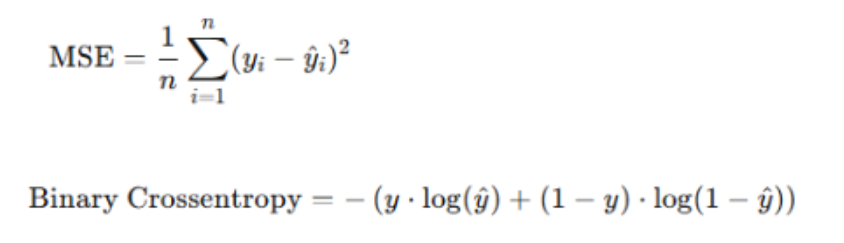

#### 손실함수(Loss Function) 설정
1. binary_crossentropy(이항 교차 엔트로피)
- y값이 이진분류인 경우 사용되는 손실함수
- 활성화함수로는 sigmoid 활용

2. categorical_crossentropy(범주형 교차 엔트로피)
- y값이 다중분류인 경우 사용되는 손실함수
- 활성화함수로는 softmax
- 라벨이 (0,1,0,0),(0,0,1,0)과 같이 원핫 인코딩된 형태로 제공된 경우 활용

3. sparse_categorical_crossentropy
- y값이 다중분류인 경우 사용되는 손실함수
- 활성화함수로는 softmax
- 라벨이 (1,2,3,4)인 경우 사용

4. mean_squared_error(평균 제곱 오차)
- y값이 연속형인 경우 사용되는 손실 함수
- 가장 흔하게 쓰임
- 대체로는 MAE(평균 절대 오차), RMSE

In [41]:
h.history

{'accuracy': [0.3489208519458771,
  0.3489208519458771,
  0.3489208519458771,
  0.3489208519458771,
  0.3489208519458771,
  0.3489208519458771,
  0.3489208519458771,
  0.3489208519458771,
  0.41366907954216003,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.6510791182518005,
  0.651079118251800

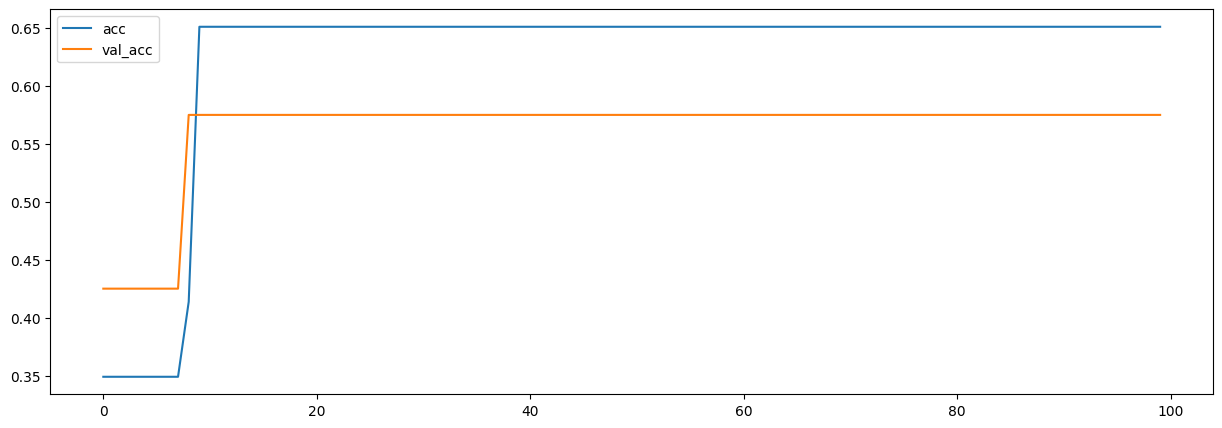

In [42]:
# 시각화
plt.figure(figsize=(15,5))
plt.plot(h.history['accuracy'], label='acc') # 훈련데이터의 정확도
plt.plot(h.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

# 시각화 해석
# 학습정확도(acc), 검증 정확도(val_acc) 모두 거의 일정한 값을 유지하고 있으며, 이 값들은 낮은 수준에 머무르고 있다.
# 이러한 패턴은 모델이 학습되지 않고 있는 상황을 나타냄

# 활성화 함수를 다시 선택, 옵티마이저 선택, 모델 구조 변경, 학습률 조정

In [43]:
h.history['accuracy']

[0.3489208519458771,
 0.3489208519458771,
 0.3489208519458771,
 0.3489208519458771,
 0.3489208519458771,
 0.3489208519458771,
 0.3489208519458771,
 0.3489208519458771,
 0.41366907954216003,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.6510791182518005,
 0.651079118

In [45]:
model2 = Sequential()
# 입력층 : Sequential에 쌓는 첫번째 층, 뉴런수는 특성의 개수
model2.add(InputLayer(shape =(30,)))


# 은닉충(중간층) : 입력층과 출력층을 제외한 다른 모든 층
model2.add(Dense(units =64, activation = 'relu'))
model2.add(Dense(units =32, activation = 'relu'))
model2.add(Dense(units =16, activation = 'relu'))

# 출력층 : 가장 마지막에 있는 층, 결과를 종합하는 층 / unit 수 = 예측하고 싶은 수(각각의 확률값)
model2.add(Dense(units =1, activation = 'sigmoid'))

In [46]:
# 학습 방법 및 평가 방법 설정
model2.compile(loss = 'binary_crossentropy',
              optimizer='adam', # SGD 업그레이드 버전, 각 파라미터에 맞는 적응형 학습률을 적용
              metrics = ['accuracy']) # 평가지표 : 분류(정확도/accuracy)

In [51]:
# 모델 학습
h = model2.fit(X_train, y_train,validation_split=0.3,
              epochs = 100) # 반복학습 횟수

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9211 - loss: 0.2078 - val_accuracy: 0.9167 - val_loss: 0.2561
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9401 - loss: 0.1465 - val_accuracy: 0.9083 - val_loss: 0.2343
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9325 - loss: 0.1965 - val_accuracy: 0.9167 - val_loss: 0.2583
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9354 - loss: 0.1778 - val_accuracy: 0.8750 - val_loss: 0.3139
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9438 - loss: 0.2049 - val_accuracy: 0.8833 - val_loss: 0.3321
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9431 - loss: 0.1515 - val_accuracy: 0.9083 - val_loss: 0.2613
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9446 - loss: 0.1280 - val_accuracy: 0.9167 - val_loss: 0.2480
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9458 - loss: 0.1556 - val_accuracy: 0.9167 - val_loss:

In [53]:
# 모델 평가
model2.evaluate(X_test, y_test)
# 손길값, 정확도

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9245 - loss: 0.1925


[0.2031935155391693, 0.9181286692619324]

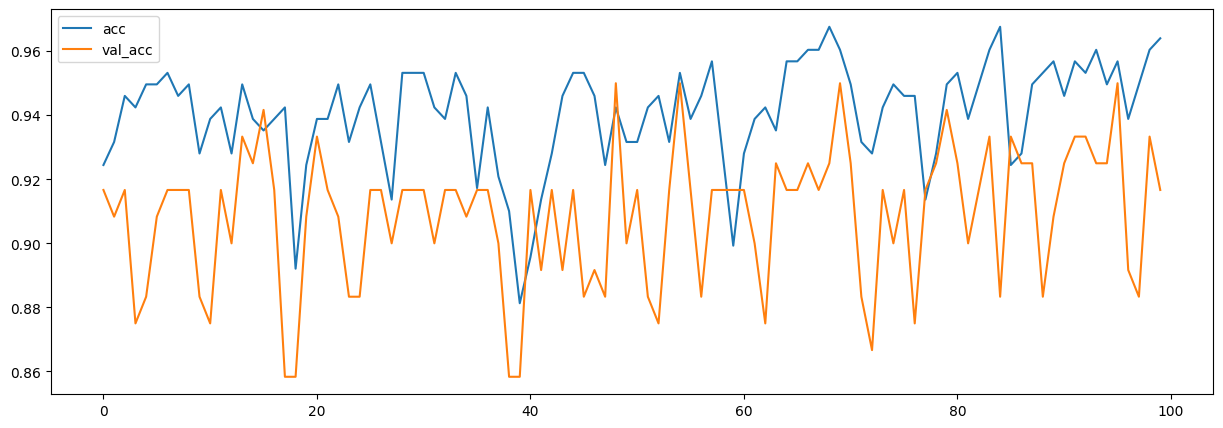

In [54]:
# 시각화
plt.figure(figsize=(15,5))
plt.plot(h.history['accuracy'], label='acc') # 훈련데이터의 정확도
plt.plot(h.history['val_accuracy'], label='val_acc')

plt.legend()
plt.show()

In [55]:
# 초기 몇 에포크 동안 정확도 급격하게 변화
# 에포크가 진행될수록 불안정한 구간도 있지만, 점차 안정화를 되찾아감